# Mapping Urban Heat at Higher Resolution: Machine Learning–Based Downscaling of ECOSTRESS LST from 70 m to 10 m in Python

by Aycha Tammour

In this notebook, i demostrate the process of downscaling ECOSTRESS Land Surface Temperature (LST) data from its native 70m resolution to 10m. I follow the approach presented in a NASA ARSET training module using Google Earth Engine, but implement it in Python using open-source libraries and data.



## How the downscaling work?

The idea is simple, we know that the low resolution ECOSTRESS LST data is correlated with the higher resolution reflectance data. This correlation means that if we have a sample of the LST data and reflectance data for the same AOI, we can train a machine learning model to learn the relationship between the two. Once we have a trained model, we can use it to predict the LST values at the higher resolution using the reflectance data as input.


```{=html}
<div class="mermaid">
flowchart LR
    A[Collect training data]
    A --> B[Target: LST at 70 m]
    A --> C[Features: Sentinel-2 Reflectance and DEM at 70 m]
    B --> D[Train Random Forest model]
    C --> D
    D --> E[Evaluate model performance]
    D --> F[Collect predictor data at 10 m resolution: Sentinel-2 Reflectance and DEM]
    F --> G[Predict LST at 10 m Resolution]
</div>
```

## Location and Dates

I selected a few cities in Europe and North Africa to demonstrate the downscaling process. The cities and relevant information are listed below in a Geopandas dataframe:

In [1]:
import geopandas as gpd
from shapely.geometry import box

locations = [
    {   "aoi_name": "cairo",
        "target_crs": "EPSG:32636",  # UTM 36N
        "bbox": (31.18, 29.95, 31.45, 30.15),
        "timezone": "Africa/Cairo",
        "start_date": "2025-08-01",
        "end_date": "2025-08-31",
    },
    {   "aoi_name": "madrid",
        "target_crs": "EPSG:32630",  # UTM 30N
        "bbox": (-3.836, 40.312, -3.524, 40.534),
        "timezone": "Europe/Madrid",
        "start_date": "2026-06-01",
        "end_date": "2026-06-29",
    },
    {   "aoi_name": "paris",
        "target_crs": "EPSG:32631",  # UTM 31N
        "bbox": (2.2, 48.75, 2.55, 48.95),
        "timezone": "Europe/Paris",
        "start_date": "2026-06-01",
        "end_date": "2026-06-29",
    },
    {   "aoi_name": "tunis",
        "target_crs": "EPSG:32632",  # UTM 32N
        "bbox": (10.00, 36.7, 10.36, 36.95),
        "timezone": "Africa/Tunis",
        "start_date": "2026-06-01",
        "end_date": "2026-06-29",
    }
]

locations_gdf = gpd.GeoDataFrame(
    [
        {
            "AOI Name": loc["aoi_name"],
            "Target CRS": loc["target_crs"],
            "Timezone": loc["timezone"],
            "Start Date": loc["start_date"],
            "End Date": loc["end_date"],
            "geometry": box(*loc["bbox"]),
        }
        for loc in locations
    ],
    crs="EPSG:4326",
)

locations_gdf.to_file("locations.geojson", driver="GeoJSON")

In [2]:
locations_gdf

,AOI Name,Target CRS,Timezone,Start Date,End Date,geometry
0,cairo,EPSG:32636,Africa/Cairo,2025-08-01,2025-08-31,"POLYGON ((31.45 29.95, 31.45 30.15, 31.18 30.1..."
1,madrid,EPSG:32630,Europe/Madrid,2026-06-01,2026-06-29,"POLYGON ((-3.524 40.312, -3.524 40.534, -3.836..."
2,paris,EPSG:32631,Europe/Paris,2026-06-01,2026-06-29,"POLYGON ((2.55 48.75, 2.55 48.95, 2.2 48.95, 2..."
3,tunis,EPSG:32632,Africa/Tunis,2026-06-01,2026-06-29,"POLYGON ((10.36 36.7, 10.36 36.95, 10 36.95, 1..."


In [3]:
aoi_name = "tunis"

In [4]:
location_info = locations_gdf.loc[locations_gdf['AOI Name'] == aoi_name].copy()

location_info.explore()

In [5]:
aoi_name = location_info['AOI Name'].values[0]
target_crs = location_info['Target CRS'].values[0]
timezone = location_info['Timezone'].values[0]
start_date = location_info['Start Date'].values[0]
end_date = location_info['End Date'].values[0]
(west, south, east, north) = location_info['geometry'].values[0].bounds
bbox = (west, south, east, north)
area = location_info.to_crs(target_crs).geometry.area.values[0]  # Area in square meters

print("Extracted Location Information:")
print("-" * 30)
print(f"AOI Name: {aoi_name}")
print(f"Area: {area/1000000:.6f} square kilometers")
print(f"Target CRS: {target_crs}")
print(f"Timezone: {timezone}")
print(f"Start Date: {start_date}")
print(f"End Date: {end_date}")
print(f"Bounding Box: (west: {west}, south: {south}, east: {east}, north: {north})")


Extracted Location Information:
------------------------------
AOI Name: tunis
Area: 890.584383 square kilometers
Target CRS: EPSG:32632
Timezone: Africa/Tunis
Start Date: 2026-06-01
End Date: 2026-06-29
Bounding Box: (west: 10.0, south: 36.7, east: 10.36, north: 36.95)


# Training Data

The data used in this notebook includes

1- ECOSTRESS LST: 70m resolution from NASA's ECOSTRESS mission
    this is the main variable we want to downscale...
2- Sentinel-2: 70m, and 10m resolution from ESA's Sentinel-2 mission
    first download at 70m to train the model, then at 10m to predict the downscaled LST
3- DEM: 30m resolution from Copernicus DEM.

For the ECOSTRESS LST data, we will use the `earthaccess` library to search for and download the relevant granules that intersect with our AOI and fall within our specified date range. I will then do some preprocessing to prepare the data for training. For the Sentinel-2 data and the DEM data, we can use the `pystac_client`, `odc-stac`, and `Xarray` to search for and download the relevant data at the desired resolution.

Unfortunately, ECOSTRESS data is only available via STAC if we are in a cloud environment (e.g. Google Colab) and not on a local machine. So for this notebook, I will demonstrate the process of searching for and downloading the ECOSTRESS LST data using `earthaccess`, and then we can use the downloaded data to train our model and perform the downscaling.

## LST Data

To get the ECOSTRESS LST data, we will use the `earthaccess` library to search for and download the relevant granules that intersect with our AOI and fall within our specified date range. This requires setting up an Earthdata account and configuring the `earthaccess` library with your credentials. Once you have that set up, you can use the following code to search for and download the ECOSTRESS LST data for our AOI and date range.

In [6]:
# Authenticate
import earthaccess

auth = earthaccess.login(persist=True)
print(auth.authenticated)

True


Now let's search for the ECOSTRESS LST data using `earthaccess`. We will specify our AOI, date range, and the collection we want to search in. Then we can download the relevant granules to our local machine.

In [7]:
# ignore warnings 
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Search
import pandas as pd

lst_granules = earthaccess.search_data(
    short_name="ECO_L2T_LSTE",
    version="002",
    bounding_box=(west, south, east, north),
    temporal=(start_date, end_date),
)
print(f"Found {len(lst_granules)} LST granules in the AOI and date range.")

Found 24 LST granules in the AOI and date range.


At this point, we only have a count of the granules. We can do a bit more filtering here to only download the granules that have good quality data. To do this, we can loop through the LST granules and check for the following conditions before downloading:

- Time range within the time range of interest (this can be checked on the fly before saving the data, by looking at the `TemporalExtent` of each granule)
- Stream the data (via earthaccess' fsspec) and check the % of valid pixels (i.e., `notnull`) in the LST band
- If the % of valid pixels is greater than a certain threshold (e.g., 75%), then save it to disk and download the associated water, cloud, and QC mask files as well.

This approach runs efficiently and helps us avoid downloading and processing granules that have a large amount of missing data, which can save time and storage space.

The script for this process is available on GitHub [here](https://github.com/astroAycha/ecostress-lst-downscaling/blob/main/granules_filter.py). The class `GranuleFilter` in that script can be used to filter the granules based on the conditions mentioned above. The filtered granules can then be downloaded to disk for further processing.

Let's have a look at an example:

In [9]:
# import and instantiate the GranuleFilter class

from granules_filter import GranuleFilter

gfilter = GranuleFilter(aoi_name=aoi_name,
                        timezone=timezone,
                        valid_pixel_threshold=0.8 # <- threshold for valid pixels
                        )

Now we can specify the time range that we are interested in. For land surface temperature, both day and night data can be interesting as they can help provide a more complete picture of the thermal environment. Nighttime data can be particularly useful for studying the urban heat island effect, as it can help identify areas that retain heat overnight.

In [10]:
# day:
start_hour = 13
end_hour = 16

In [ ]:
# night
# start_hour = 1
# end_hour = 4

Now we run the `keep_valid_granules` function to filter the granules we found through the `earthaccess` search. This function will check the time range and the % of valid pixels in the LST band for each granule, and only download the granules that meet our criteria.

In [ ]:
# Download the granules that meet the filtering criteria
good_granules = gfilter.keep_valid_granules(lst_granules, 
                                            local_hour_range=(start_hour, end_hour))


  Skipping 14_32SNF_20260606T151250_0713_01_LST.tif: valid fraction 0.10 below threshold 0.8
  Skipping 14_32SPG_20260606T151250_0713_01_LST.tif: valid fraction 0.01 below threshold 0.8
  Skipping 15_32SNF_20260606T151342_0713_01_LST.tif: valid fraction 0.48 below threshold 0.8


QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

Skipping (hour 8 outside 13–16): 2026-06-10T07:07:14.236Z
  Skipping 15_32SPF_20260610T133809_0713_01_LST.tif: valid fraction 0.63 below threshold 0.8
  Skipping 15_32SNF_20260610T133809_0713_01_LST.tif: valid fraction 0.24 below threshold 0.8
  Skipping 15_32SPG_20260610T133809_0713_01_LST.tif: valid fraction 0.69 below threshold 0.8
Skipping (hour 6 outside 13–16): 2026-06-14T05:33:46.171Z
Skipping (hour 11 outside 13–16): 2026-06-18T10:30:39.535Z
Skipping (hour 11 outside 13–16): 2026-06-18T10:30:39.535Z
Skipping (hour 11 outside 13–16): 2026-06-18T10:30:39.535Z
Skipping (hour 3 outside 13–16): 2026-06-22T02:25:19.824Z
Skipping (hour 3 outside 13–16): 2026-06-22T02:25:19.824Z
Skipping (hour 9 outside 13–16): 2026-06-22T08:56:33.610Z
Skipping (hour 9 outside 13–16): 2026-06-22T08:56:33.610Z
Skipping (hour 9 outside 13–16): 2026-06-22T08:56:33.610Z
Skipping (hour 1 outside 13–16): 2026-06-26T00:50:39.434Z
Skipping (hour 1 outside 13–16): 2026-06-26T00:50:39.434Z
Skipping (hour 8 outsi

In [21]:
print(f"\nKept {len(good_granules)} clean granules for {aoi_name} for the time range: {start_hour}-{end_hour} LST.")


Kept 2 clean granules for tunis for the time range: 13-16 LST.


Let's have a look at what was downloaded. The script creates a directory for the AOI data and saves the granules that meet the filtering criteria there. 
The filtering process reduced the number of files and the size of the data that we need to download, which can save time and storage space. The downloaded files include the LST data, water mask, cloud mask, and QC mask for each granule that meets the filtering criteria.

In [18]:
! ls -sh {gfilter.aoi_name}_ecostress_data

total 7.7M
8.0K ECOv002_L2T_LSTE_44901_015_32SPF_20260606T151342_0713_01_cloud.tif
3.4M ECOv002_L2T_LSTE_44901_015_32SPF_20260606T151342_0713_01_LST.tif
572K ECOv002_L2T_LSTE_44901_015_32SPF_20260606T151342_0713_01_QC.tif
 16K ECOv002_L2T_LSTE_44901_015_32SPF_20260606T151342_0713_01_water.tif
8.0K ECOv002_L2T_LSTE_44901_015_32SPG_20260606T151342_0713_01_cloud.tif
3.2M ECOv002_L2T_LSTE_44901_015_32SPG_20260606T151342_0713_01_LST.tif
632K ECOv002_L2T_LSTE_44901_015_32SPG_20260606T151342_0713_01_QC.tif
 12K ECOv002_L2T_LSTE_44901_015_32SPG_20260606T151342_0713_01_water.tif


`good_granules` is a list of the granules that were downloaded and meet the filtering criteria. Let's have a look at what is inside the list:

In [24]:
from pprint import pprint
pprint(good_granules[0])

{'cloud_file': 'tunis_ecostress_data\\ECOv002_L2T_LSTE_44901_015_32SPG_20260606T151342_0713_01_cloud.tif',
 'granule': Collection: {'ShortName': 'ECO_L2T_LSTE', 'Version': '002'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': 10.123185609105322, 'EastBoundingCoordinate': 11.38648743178623, 'NorthBoundingCoordinate': 37.94208531976598, 'SouthBoundingCoordinate': 36.93487993376639}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2026-06-06T15:13:42.388Z', 'EndingDateTime': '2026-06-06T15:14:34.357Z'}}
Size(MB): 17.31
Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/ECO_L2T_LSTE.002/ECOv002_L2T_LSTE_44901_015_32SPG_20260606T151342_0713_01/ECOv002_L2T_LSTE_44901_015_32SPG_20260606T151342_0713_01_water.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/ECO_L2T_LSTE.002/ECOv002_L2T_LSTE_44901_015_32SPG_20260606T151342_0713_01/ECOv002_L2T_LSTE_44901_015_32SPG_20260606T151342_0

Let's save the filtered granules' information in a json file for future reference. This will allow us to easily access the list of granules that meet our criteria without having to repeat the filtering process.

In [26]:
import json

def serialize_entry(entry):
    return {
        'granule': dict(entry['granule']), 
        'lst_file': entry['lst_file'],
        'water_file': entry['water_file'],
        'qc_file': entry['qc_file'],
        'cloud_file': entry['cloud_file']
    }

serializable = [serialize_entry(e) for e in good_granules]

with open(f'{aoi_name}_{start_hour}_{end_hour}_granules.json', 'w') as f:
    json.dump(serializable, f, indent=2, default=str)  # default=str catches any stray datetimes

### LST Data Processing and Stacking

So far here is how the process 

Before we use the data, we need to perform some preprocessing steps. This includes:
- QC masking to keep only good quality pixels
- Cloud masking to remove pixels that are affected by clouds
- Water mask to keep only land pixels
- Clip the data to our AOI

The script is available on GitHub [here](https://github.com/astroAycha/ecostress-lst-downscaling/blob/main/preprocess_lst.py).

The diagram below illustrates the steps involved in the preprocessing and stacking of the LST data:

```{=html}
<div class="mermaid">
flowchart LR
    A[Search] --> B[Filter\ndate + time + valid pixels]
    B --> C[Download]
    C --> D[QC mask\nwater mask\n cloud mask\nclip to AOI]
    D --> E[Stack]
</div>
```

We need to pause here for a moment to check the data we have. The AOI we choose may not be fully covered by one single tile. We can check the tiles from the file names which include parts such as `32SPG` and `32SPF`. 
`32S` here is just the UTM zone. `PG` and `PF` are the tile indentifiers in the [Military Grid Reference System](https://en.wikipedia.org/wiki/Military_Grid_Reference_System) (MGRS) tile codes which is used in ECOSTRESS (it is the same tiling system used by Sentinel-2 and HLS).
This means we need to be careful when we stack the data to handle the tiles separately.

Let's start by writing a function to group the granules by tile. This will allow us to handle the tiles separately when we stack the data.
The function reads the json file that we saved earlier and groups the granules by tile:

In [30]:
from collections import defaultdict
import json

def group_granules_by_tile(json_file_path):
    with open(json_file_path) as f:
        loaded = json.load(f)

    tiles = defaultdict(list)
    for entry in loaded:
        # normalize \ and / then take just the filename
        filename = entry['lst_file'].replace('\\', '/').split('/')[-1]
        tile_id = filename.split('_')[-5]
        tiles[tile_id].append(entry)

    return dict(tiles)

In [31]:
tiles = group_granules_by_tile(f'{aoi_name}_{start_hour}_{end_hour}_granules.json')
print(list(tiles.keys()))

['32SPG', '32SPF']


Whether we end up with one tile or multiple tiles for the selected AOI, there are a few steps that we need to take care of to ensure our final product is a good quality LST image. A reminder that at this stage we are still working with the 70 m resolution LST data that will be used in training the ML model which we use to downscale the LST data to 10 m resolution. 

The steps involved in building the composites are as follows:
1. Group the granules by tile (already done in the previous step)
2. For each tile, applying QC, cloud and water masks to each granule's LST
3. Reproject each masked LST to a common grid defined by the AOI and target CRS
4. Average the reprojected LSTs across time to create a composite for that tile.

For every step of masking and for the cliping, we do a check to make sure that there is a decent amount of valid pixels left in the data. If the number of valid pixels is too low, we can discard that granule from the stack. This is important to ensure that we have enough data to create a meaningful composite.

Once we have proccessed the LST data, we can stack the granules and create a mean composite for our AOI.

As a first step before creating the composite, we create a reference grid for the AOI. This grid will be used to reproject the LST data to a common grid before averaging. The reference grid is defined by the AOI and the target CRS (Coordinate Reference System), and the resolution of the grid is set to 70 m to match the resolution of the LST data.

In [33]:
from build_composite import build_reference_grid

resolution = 70  # ECOSTRESS native resolution, meters
transform, shape = build_reference_grid(bbox, target_crs, resolution)

Now we move to creating the composite for each tile. The input parameters for this function are a list of granules for the tile, the AOI bounding box, the target CRS and reference grid and the maximum cloud cover threshold. The function will return a composite LST DataArray for the tile, or None if there are no valid granules for the tile.

In [34]:
from build_composite import build_composite

max_cloud_cover = 5 # percent. Feel free to experiment with this.

tile_composites = {}
for tile_id, entries in tiles.items():
    print("*" * 50)
    print(f" >>> Building composite for tile {tile_id} ({len(entries)} granules)")
    print("*" * 50)
    composite = build_composite(entries, 
                                bbox, 
                                target_crs, 
                                transform, shape,
                                max_cloud_cover=max_cloud_cover)
    if composite is not None:
        tile_composites[tile_id] = composite

**************************************************
 >>> Building composite for tile 32SPG (1 granules)
**************************************************
  QC mask applied >>> 98.5% pixels retained
 >>> Skipping: granule does not meaningfully overlap AOI
 >>> No usable granules for this tile after QC, water, and cloud masking ❗
**************************************************
 >>> Building composite for tile 32SPF (1 granules)
**************************************************
  QC mask applied >>> 99.4% pixels retained
  Cloud cover in AOI: 0.0%
 --->>> Building composite from the following acquisition dates:
['2026-06-06T15:13:42.388Z']


Note, how we skipped one granule in the stack because it did not "meaningfully" overlap with out AOI. This is triggered by the `NoDataInBounds` or `OneDimensionalRaster` errors as a result of clipping the granule to the AOI.

In the next step, we merge the tile composites into a single composite. Obviously in this case we only have one tile but in other cases we may have multiple so let's go over the process of merging the tiles. 
The main thing that is worth highlighting here is that the code performs a feathering of the edges of the tiles to avoid sharp transitions between the tiles in the final composite. There are a few ways this can be done, in this case we apply a weighted average of the overlapping pixels where the weights are based on the distance from the edge of the tile. This helps to create a smooth transition between the tiles in the final composite.

In [38]:
from build_composite import merge_tiles

lst_mosaic_70m_K = merge_tiles(tile_composites, 
                        target_crs,
                        feather_px=15 # <- number of pixels to feather the edges
                        )

We can now save the file as a GeoTIFF. This the final mosiac at 70 m resolution for the LST in Kelvin.

In [ ]:
# save the mosaic
lst_mosaic_70m_path = f"./products/{aoi_name}_{start_hour}_{end_hour}_lst_mosaic_70m_K.tif"
lst_mosaic_70m_K.rio.to_raster(lst_mosaic_70m_path, 
                         driver="GTiff",
                         dtype="float32")

Let's have a quick look at the LST mosiac 1t 70 m resolution:

In [40]:
lst_mosaic_70m_K

<xarray.DataArray (y: 402, x: 464)> Size: 1MB
array([[         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       [         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       [         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       ...,
       [         nan,          nan,          nan, ..., 304.5       ,
        304.22000122, 302.04000854],
       [         nan,          nan,          nan, ..., 305.1000061 ,
        303.23999023, 304.94000244],
       [         nan,          nan,          nan, ..., 304.33999634,
        305.79998779, 303.51998901]], shape=(402, 464))
Coordinates:
  * x            (x) float64 4kB 5.891e+05 5.891e+05 ... 6.214e+05 6.215e+05
  * y            (y) float64 3kB 4.09e+06 4.09e+06 ... 4.062e+06 4.062e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:  nan

We can also make a quick plot to see how the final composite looks like. The plot shows the LST values in Kelvin, with the color scale indicating the temperature range

In [43]:
import hvplot.xarray

lst_mosaic_70m_K.rio.reproject("EPSG:4326").hvplot.image(x="x", 
                                                   y="y", 
                                                   rasterize=True, 
                                                   cmap="coolwarm", 
                                                   title="LST", 
                                                   frame_width=400, 
                                                   frame_height=400,
                                                   geo=True)

BokehModel(combine_events=True, render_bundle={'docs_json': {'b0a0b062-2286-4306-961f-699821f07b27': {'version…

Now that we are done with the hard stuff, let's move on to the next step which is to get the rest of the training data: Sentinel-2 reflectance data and the Copernicus DEM data in both 70 m resolution.

## Sentinel-2 data:

We can now use the `pystac_client` and `odc-stac` libraries to search for and download the Sentinel-2 data for our AOI and date range. We will need to specify the collection we want to search in (e.g. "sentinel-2-l2a") and the bands we want to download (e.g. B02, B03, B04, B08). We can also specify the resolution we want to download at (e.g. 10m or 20m).

I went through this process in detail in two previous notebooks [here]() and [here](), so I won't repeat the details again. A lot of what was done for the ECOSTRESS LST data in terms of searching, and aligning the data to the same grid is now done using the `odc-stac` library, which makes it much easier to work with the data in Python.

In [22]:
import pystac_client
import odc.stac

In [61]:
from datetime import datetime, timedelta

# parse your existing ECOSTRESS params
eco_start = datetime.strptime(start_date, "%Y-%m-%d").replace(hour=start_hour)
eco_end   = datetime.strptime(end_date,   "%Y-%m-%d").replace(hour=end_hour)

# S2 doesn't need hour precision — just use the date range
# optionally pad by a few weeks on each side for better cloud-free coverage
pad_days = 15
s2_start = (eco_start - timedelta(days=pad_days)).strftime("%Y-%m-%d")
s2_end   = (eco_end   + timedelta(days=pad_days)).strftime("%Y-%m-%d")

In [62]:
print(eco_start, eco_end)
print(s2_start, s2_end)

2026-06-01 13:00:00 2026-06-27 16:00:00
2026-05-17 2026-07-12


In [63]:

s2_catalog = pystac_client.Client.open("https://earth-search.aws.element84.com/v1")

s2_items = s2_catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime=f"{s2_start}/{s2_end}",
    query={"eo:cloud_cover": {"lt": 10}}
).item_collection()

print(f"Found {len(s2_items)} Sentinel-2 items in the AOI and date range.")

Found 8 Sentinel-2 items in the AOI and date range.


In [64]:
s2_70_ds = odc.stac.load(
    s2_items,
    bbox=bbox,
    bands=["red", "green", "blue", "nir"],
    resolution=70, # <- use the same resolution as the LST data
    chunks={},
    groupby="solar_day",
    crs="EPSG:32617",
    resampling="bilinear",
)

In [65]:
s2_70_ds

<xarray.Dataset> Size: 15MB
Dimensions:      (y: 543, x: 489, time: 7)
Coordinates:
  * y            (y) float64 4kB 9.376e+06 9.376e+06 ... 9.338e+06 9.338e+06
  * x            (x) float64 4kB 5.474e+06 5.474e+06 ... 5.508e+06 5.508e+06
    spatial_ref  int32 4B 32617
  * time         (time) datetime64[ns] 56B 2026-05-22T11:07:23.165000 ... 202...
Data variables:
    red          (time, y, x) uint16 4MB dask.array<chunksize=(1, 543, 489), meta=np.ndarray>
    green        (time, y, x) uint16 4MB dask.array<chunksize=(1, 543, 489), meta=np.ndarray>
    blue         (time, y, x) uint16 4MB dask.array<chunksize=(1, 543, 489), meta=np.ndarray>
    nir          (time, y, x) uint16 4MB dask.array<chunksize=(1, 543, 489), meta=np.ndarray>

In [66]:
from rasterio.enums import Resampling

# force S2 onto exactly the same grid as LST
s2_70_ds_matched = s2_70_ds.rio.reproject_match(lst_mosaic, 
                                                resampling=Resampling.average
                                                )

# verify
print("LST shape:", lst_mosaic.shape)
print("S2 shape: ", s2_70_ds_matched["blue"].mean(dim="time").shape)
print("LST bounds:", lst_mosaic.rio.bounds())
print("S2 bounds: ", s2_70_ds_matched.rio.bounds())

LST shape: (321, 370)
S2 shape:  (321, 370)
LST bounds: (441193.93255634734, 5399735.927550922, 467093.93255634734, 5422205.927550922)
S2 bounds:  (441193.93255634734, 5399735.927550922, 467093.93255634734, 5422205.927550922)


In [67]:
import numpy as np

# squeeze time dim and take mean composite 
blue_70 = s2_70_ds_matched["blue"].mean(dim="time").values.astype(float)
green_70 = s2_70_ds_matched["green"].mean(dim="time").values.astype(float)
red_70 = s2_70_ds_matched["red"].mean(dim="time").values.astype(float)
nir_70 = s2_70_ds_matched["nir"].mean(dim="time").values.astype(float)

# DEM data

We do the same for the elevation data. Elevation might not have a big impact for our AOI since Toronto is relatively flat, but it is better to include it as a predictor in our model just in case it does have some influence on the LST values and to be consistent with the approach used in the NASA ARSET training module.

In [68]:
dem_catalog = pystac_client.Client.open(
    "https://earth-search.aws.element84.com/v1"
)

dem_items = dem_catalog.search(
    collections=["cop-dem-glo-30"],
    bbox=bbox
).item_collection()

print(f"Found {len(dem_items)} DEM items")

Found 1 DEM items


In [69]:
import odc.stac

dem_70_ds = odc.stac.load(
    dem_items,
    bbox=bbox,
    bands=["data"],
    resolution=70, # <- use the same resolution as the LST data
    chunks={},
    crs="EPSG:32617",
    resampling="bilinear"
)

In [70]:
dem_70_ds

<xarray.Dataset> Size: 1MB
Dimensions:      (y: 543, x: 489, time: 1)
Coordinates:
  * y            (y) float64 4kB 9.376e+06 9.376e+06 ... 9.338e+06 9.338e+06
  * x            (x) float64 4kB 5.474e+06 5.474e+06 ... 5.508e+06 5.508e+06
    spatial_ref  int32 4B 32617
  * time         (time) datetime64[ns] 8B 2021-04-22
Data variables:
    data         (time, y, x) float32 1MB dask.array<chunksize=(1, 543, 489), meta=np.ndarray>

In [71]:
# force DEM onto exactly the same grid as LST
dem_70_matched = dem_70_ds.rio.reproject_match(lst_mosaic, 
                                                resampling=Resampling.average
                                                )
# squeeze dem
dem_70 = dem_70_matched["data"].squeeze().values.astype(float)

# verify
print("LST shape:", lst_mosaic.shape)
print("DEM shape: ", dem_70.shape)
print("LST bounds:", lst_mosaic.rio.bounds())
print("DEM bounds: ", dem_70_matched.rio.bounds())

LST shape: (321, 370)
DEM shape:  (321, 370)
LST bounds: (441193.93255634734, 5399735.927550922, 467093.93255634734, 5422205.927550922)
DEM bounds:  (441193.93255634734, 5399735.927550922, 467093.93255634734, 5422205.927550922)


In [72]:
# derive land_mask from the water-masked mosaic
# pixels that survived clip_and_water_mask_lst are land; water pixels are NaN
land_mask = np.isfinite(lst_mosaic.values)
print(f"Land pixels in mosaic: {land_mask.sum()} / {land_mask.size}")

Land pixels in mosaic: 118556 / 118770


In [73]:
print("lst:       ", lst_mosaic.shape)
print("land_mask: ", land_mask.shape)
print("blue:      ", blue_70.shape)
print("green:     ", green_70.shape)
print("red:       ", red_70.shape)
print("nir:       ", nir_70.shape)
print("elev:      ", dem_70.shape)

lst:        (321, 370)
land_mask:  (321, 370)
blue:       (321, 370)
green:      (321, 370)
red:        (321, 370)
nir:        (321, 370)
elev:       (321, 370)


In [74]:
lst = lst_mosaic.values.astype(float)  # extract numpy array from xarray

# combined mask — land + valid LST + valid S2 + valid DEM
mask = (
    land_mask            &   # water mask
    np.isfinite(lst)     &   # valid LST
    (lst > 0)            &   # no zero LST
    np.isfinite(blue_70)      &   # valid S2
    np.isfinite(green_70)      &
    np.isfinite(red_70)      &
    np.isfinite(nir_70)      &
    np.isfinite(dem_70)        # valid DEM
)

print(f"Valid training pixels after all masks: {mask.sum()}")

Valid training pixels after all masks: 118556


In [75]:
# flatten
def flat(arr):
    return arr[mask].ravel()

X_full = np.column_stack([flat(blue_70), 
                          flat(green_70), 
                          flat(red_70), 
                          flat(nir_70),
                          flat(dem_70)
                          ])
y_full = flat(lst)

print(f"X shape: {X_full.shape}")
print(f"y range: {y_full.min():.1f} — {y_full.max():.1f} K")

X shape: (118556, 5)
y range: 293.2 — 325.1 K


In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_full, 
                                                    y_full, 
                                                    test_size=0.2, 
                                                    random_state=11)
print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")

Training samples: 94844, Testing samples: 23712


In [85]:
# # S2 nodata is often 0 — treat 0 as invalid
# valid_s2 = (
#     np.isfinite(blue_70) & (blue_70 > 0) &
#     np.isfinite(green_70) & (green_70 > 0) &
#     np.isfinite(red_70) & (red_70 > 0) &
#     np.isfinite(nir_70) & (nir_70 > 0)
# )
# print(f"Valid S2 pixels with >0 check: {valid_s2.sum()}")

In [77]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50, 
                           random_state=79, 
                           n_jobs=-1)
rf.fit(X_train, y_train)

,n_estimators,50
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [78]:
from sklearn.metrics import mean_absolute_error as mae

y_pred = rf.predict(X_test)
error = mae(y_test, y_pred)
print(f"Mean Absolute Error: {error:.2f} K")

Mean Absolute Error: 1.96 K


In [45]:
#TODO: Add feature importance plot, partial dependence plots, and error scatter plot

# Prediction and evaluation

For the prediction step, we will use a machine learning model to learn the relationship between the low resolution LST data and the high resolution reflectance data. We can use a simple regression model for this, such as a Random Forest or a Gradient Boosting Regressor. We will train the model using the 10m resolution data, and then use it to predict the LST values at 70m resolution using the reflectance data as input.

## to 10m

In [79]:
# load S2 at 10m
s2_10_ds = odc.stac.load(
    s2_items,
    bbox=bbox,
    bands=["blue", "green", "red", "nir"],
    resolution=10,
    chunks={},
    groupby="solar_day",
    crs="EPSG:32617",
    resampling="bilinear",
)


In [80]:
blue_10 = s2_10_ds["blue"].mean(dim="time").values.astype(float)
green_10 = s2_10_ds["green"].mean(dim="time").values.astype(float)
red_10 = s2_10_ds["red"].mean(dim="time").values.astype(float)
nir_10 = s2_10_ds["nir"].mean(dim="time").values.astype(float)

In [81]:
# reproject DEM to 10m
dem_10_matched = dem_70_ds["data"].rio.reproject_match(s2_10_ds,
                                                resampling=Resampling.bilinear)

dem_10 = dem_10_matched.squeeze().values.astype(float)

In [82]:

# valid mask at 10m
mask_10 = (
    np.isfinite(blue_10)  & (blue_10 > 0)  &
    np.isfinite(green_10) & (green_10 > 0) &
    np.isfinite(red_10)   & (red_10 > 0)   &
    np.isfinite(nir_10)   & (nir_10 > 0)   &
    np.isfinite(dem_10)
)

In [83]:
X_pred_10 = np.column_stack([blue_10[mask_10], 
                             green_10[mask_10], 
                             red_10[mask_10], 
                             nir_10[mask_10],
                             dem_10[mask_10]])

print(f"Predicting over {X_pred_10.shape[0]} pixels at 10m...")
y_pred_10 = rf.predict(X_pred_10)

Predicting over 12974349 pixels at 10m...


In [84]:
# reconstruct 2D
lst_10m = np.full(mask_10.shape, np.nan)
lst_10m[mask_10] = y_pred_10

print(f"LST 10m shape: {lst_10m.shape}")
print(f"Value range:   {np.nanmin(lst_10m):.1f} — {np.nanmax(lst_10m):.1f} K")

LST 10m shape: (3797, 3417)
Value range:   294.9 — 321.0 K


In [85]:
import xarray as xr

# wrap 10m prediction as DataArray
lst_10m_da = xr.DataArray(
    lst_10m,
    dims=["y", "x"],
    coords={"y": s2_10_ds.y, "x": s2_10_ds.x}
).rio.write_crs("EPSG:32617")

# aggregate prediction back to 70m
lst_pred_agg = lst_10m_da.rio.reproject_match(
    lst_mosaic, resampling=Resampling.average
)

# residual = original 70m LST - aggregated prediction
residual_70m = lst_mosaic - lst_pred_agg

# resample residual to 10m (bilinear = smooth surface)
residual_10m = residual_70m.rio.reproject_match(
    lst_10m_da, resampling=Resampling.bilinear
)

# final bias-corrected 10m LST
lst_final = lst_10m_da + residual_10m

print(f"Final LST 10m range: {float(lst_final.min()):.1f} — {float(lst_final.max()):.1f} K")

Final LST 10m range: 286.1 — 329.9 K


In [86]:
print(f"Residual mean: {float(residual_70m.mean()):.2f} K")
print(f"Residual std:  {float(residual_70m.std()):.2f} K")
print(f"Residual max abs: {float(abs(residual_70m).max()):.2f} K")

Residual mean: 0.37 K
Residual std:  2.71 K
Residual max abs: 15.28 K


In [87]:
# convert to Celsius for easier reading
lst_70m_C = lst_mosaic - 273.15
lst_10m_C = lst_final - 273.15

In [88]:
lst_70m_C.rio.to_raster(f"./products/{aoi_name}_{start_hour}_{end_hour}_lst_70m_C.tif",
                         driver="GTiff",
                            dtype="float32")

In [89]:
lst_10m_C.rio.to_raster(f"./products/{aoi_name}_{start_hour}_{end_hour}_lst_10m_C.tif",
                         driver="GTiff",
                            dtype="float32")

In [199]:
import leafmap
import numpy as np
import rasterio

def plot_lst_comparison(lst_70m: str, 
                         lst_10m: str,
                         title_70m: str = "LST 70m (ECOSTRESS)",
                         title_10m: str = "LST 10m (Sharpened)"):
    """
    Display 70m and 10m LST side-by-side with a draggable split slider.

    Parameters
    ----------
    lst_70m : str
        Path to 70m composite LST in Kelvin, with CRS set.
    lst_10m : str
        Path to 10m sharpened LST in Kelvin, with CRS set.
    """

    def get_stats(path):
        with rasterio.open(path) as src:
            arr = src.read(1)
            return np.nanpercentile(arr, 2), np.nanpercentile(arr, 98)

    vmin1, vmax1 = get_stats(lst_70m)
    vmin2, vmax2 = get_stats(lst_10m)

    vmin = min(vmin1, vmin2)
    vmax = max(vmax1, vmax2)

    m = leafmap.Map(basemap="Esri.WorldImagery")

    m.split_map(
        left_layer=lst_70m,
        right_layer=lst_10m,
        left_label=title_70m,
        right_label=title_10m,
        left_args={
            "colormap": "RdYlBu_r",
            "vmin": vmin,
            "vmax": vmax,
            "opacity": 0.8,
        },
        right_args={
            "colormap": "RdYlBu_r",
            "vmin": vmin,
            "vmax": vmax,
            "opacity": 0.8,
        },
    )

    return m



In [200]:

# usage
m = plot_lst_comparison(
    lst_70m=".\\products\\paris_0_5_lst_70m_C.tif",
    lst_10m=".\\products\\paris_0_5_lst_10m_C.tif",
    title_70m="LST 70m — Paris June/July 2025",
    title_10m="LST 10m — Sharpened"
)
m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [171]:
m.to_html("lst_comparison_paris.html")

In [182]:
# from IPython.display import IFrame
# map_path = "./lst_comparison_paris.html"
# IFrame(map_path, width="100%", height=500)

##  Land Surface Temperature Range (DLSTR)

LST_day - LST_night = DLSTR
DLSTR is the maximum daytime LST − minimum nighttime LST (or day minus night observations from fixed satellite overpasses).

In [91]:
import rioxarray as rxr

day = rxr.open_rasterio(f"./products/paris_13_16_lst_10m_C.tif", masked=True).squeeze()
night = rxr.open_rasterio(f"./products/paris_1_4_lst_10m_C.tif", masked=True).squeeze()

dtr = day - night

In [92]:
dtr.rio.to_raster(f"./products/{aoi_name}_lst_dtr_10m.tif")

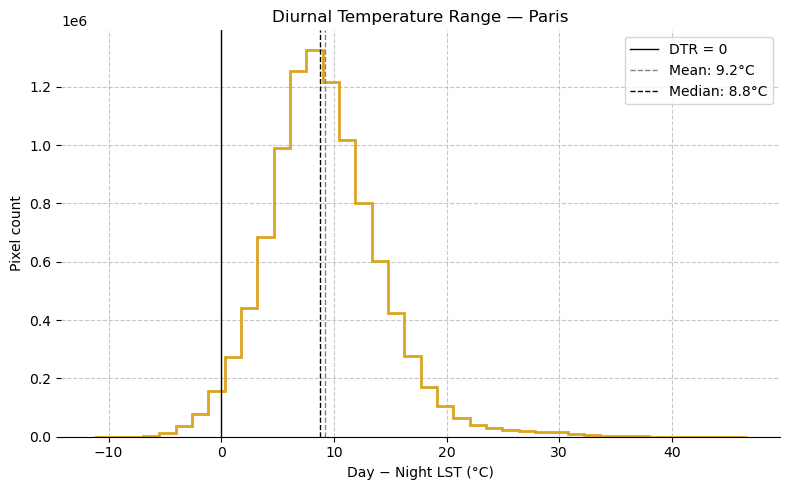

In [93]:
import matplotlib.pyplot as plt
import numpy as np

# flatten and drop NaNs
vals = dtr.values.flatten()
vals = vals[~np.isnan(vals)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(vals, histtype='step', bins=40, color="w",  lw=2, edgecolor="goldenrod")

ax.axvline(0, color="black", linewidth=1, linestyle="-", label="DTR = 0")
ax.axvline(np.mean(vals), color="grey", linewidth=1, linestyle="--", label=f"Mean: {np.mean(vals):.1f}°C")
ax.axvline(np.median(vals), color="k", linewidth=1, linestyle="--", label=f"Median: {np.median(vals):.1f}°C")

ax.set_xlabel("Day − Night LST (°C)")
ax.set_ylabel("Pixel count")
ax.set_title("Diurnal Temperature Range — Paris")
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Acknowledgement:

This exercise is based on the NASA ARSET training module on downscaling ECOSTRESS LST data using Google Earth Engine. The original training module can be found [here](https://www.earthdata.nasa.gov/learn/trainings/introduction-thermal-remote-sensing-applications-urban-heat-island-mapping). I have adapted the approach presented in the training module to work in Python using open-source libraries and data.

## Useful Links

- [Introduction to Thermal Remote Sensing and Applications in Urban Heat Island Mapping](https://www.earthdata.nasa.gov/learn/trainings/introduction-thermal-remote-sensing-applications-urban-heat-island-mapping)
- [Introduction to `earthaccess`](https://github.com/nasa/LPDAAC-Data-Resources/blob/main/python/tutorials/earthaccess_introduction.ipynb)
- [ECOSTRESS Data Resouces on GitHub](https://github.com/nasa/ECOSTRESS-Data-Resources)
- [Working with ECOSTRESS Tiled Data](https://github.com/nasa/ECOSTRESS-Data-Resources/blob/20dfefbfb793d924aa6b222ddc4c9464e66ff4a6/python/tutorials/Working_with_ECOSTRESS_Tiled_data.ipynb)
- [Ecostress L2 Product Specification Document](https://lpdaac.usgs.gov/documents/380/ECO2_PSD_V1.pdf)

In [76]:
import datetime

print(f"Last updated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Last updated: 2026-06-25 13:09:56
